# Application of WAVEGUISE to an interference pattern observed by AIRS
This script is to show in detail how WAVEGUISE is applied to a complex 2-D data set and how it retrieves wave packets.

### Overview of functions in use
**waveguise** contains:
- **waveguise_2d.BG_removal()**: Splits the data into a low-frequency background and high frequency wave field.
- **waveguise_2d.denoise_2d()**: Denoises the data.
- **waveguise_2d.wavefield_segmentation_2d()**: Provides labels that group wave packets in the wavelet amplitude spectrum.
- **waveguise_2d.find_clusters_logk_theta()**: Joins segments that share spectral properties.
- **waveguise_2d.build_cluster_map_with_noise()**: Builds a map from previous labels to new labels
- **waveguise_2d.relabel_by_xy_overlap()**: Separates segments again if they do not overlap.
- **waveguise_2d.variance_filter()**: Filters wave packets that do not contribute much variance.
- **waveguise_2d.recon_allWP_2d()**: Reconstructs all wave packets and computes instantaneous spectral properties.
- **waveguise_2d.kxky_2_lhtheta()**: Computes wavelengths and orientations from k components

**juwavelet** contains:
- **utils.smooth_edges()**: Tapers the data set to suppress edge effects in the spectral analysis. 
- **transform.decompose2d()**: Computes the 2-D continuous wavelet transform of a signal.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parents[1] / "scripts"))
sys.path.append(str(Path.cwd().parents[2] / "juwavelet"))
import juwavelet.transform as transform
from juwavelet import utils
import waveguise_2d as two
import plot_tools as pt

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import copy
import matplotlib.colors as mcolors
import time
from datetime import datetime, timedelta

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
data_path = str(Path.cwd().parents[1] / 'data/pert_airs_l1_2022_015.nc')
ds = xr.open_dataset(data_path)

# Second Antarctic Overpass

In [6]:
track_slice = slice(17_480,17_650)
lon = ds["lon"].isel(NTRACK=track_slice)
lat = ds["lat"].isel(NTRACK=track_slice)

orig = ds["bt_4mu_pt"].isel(NTRACK=track_slice)
orig_copy = orig.copy()
BI_high, BI_low = two.BG_removal(orig_copy.values)
dx, dy = 20_000, 20_000
nx, ny = orig['NTRACK'].size, orig['NXTRACK'].size
y = np.linspace(0,(ny-1)*dy,ny)*1e-3
x = np.linspace(0,(nx-1)*dx,nx)*1e-3

nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(BI_high, ntap, window='tukey')

print(f"Data size: {signal.shape[0]:.0f}x{signal.shape[1]:.0f}")

Data size: 170x90


In [7]:
s0 = 2 #smallest scale that we wanna resolve
s1 = 0.5 * min([nx,ny]) #largest scale we wanna resolve (since the first Fourier component is part of the background (BI_low) the largest scale fits twice in the domain)
dj = 1 / 8 # apäter wieder dj=1/8
js = int(1/dj*np.log2(s1/s0))
jt = 31

cwt_result = transform.decompose2d(signal,dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1,nxpad=None,nypad=None,opts={'param': 10},mode="scaled",dtype=np.complex128)

print(f"The data resolution is {dx*1e-3:.0f} km and the smallest wavelength you analyze is {cwt_result['period'][0]*1e-3:.0f} km.")
print(f"The data domain is at least {min([nx,ny])*dx*1e-3:.0f} km and the largest wavelength you analyze is {cwt_result['period'][-1]*1e-3:.0f} km.")

params = {
    "Smallest scale (s0)": f"{s0:.0f}",
    "Largest scale (s1)": f"{s1:.0f}",
    "Scale sampling (dj)": f"{dj:.3f}",
    "Number of scales (js)": f"{js:.0f}",
    "Number of azimuth angles (jt)": f"{jt:.0f}",
    "Non-dimensional frequency": f"{cwt_result['opts']['param']:.2f}",
}
label_width = max(len(label) for label in params)
for label, value in params.items():
    print(f"{label:<{label_width}} : {value}")

/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))


The data resolution is 20 km and the smallest wavelength you analyze is 25 km.
The data domain is at least 1800 km and the largest wavelength you analyze is 478 km.
Smallest scale (s0)           : 2
Largest scale (s1)            : 45
Scale sampling (dj)           : 0.125
Number of scales (js)         : 35
Number of azimuth angles (jt) : 31
Non-dimensional frequency     : 10.00


/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


In [8]:
# Denoising
noise_level = 0.03 #units of BI
wavy_stuff, denoised_cwt = two.denoise_2d(cwt_result,white_noise_level=4*noise_level,sMAD_threshold=None,mean_axis=(1,2,3))

Text(0.03, 0.94, 'c')

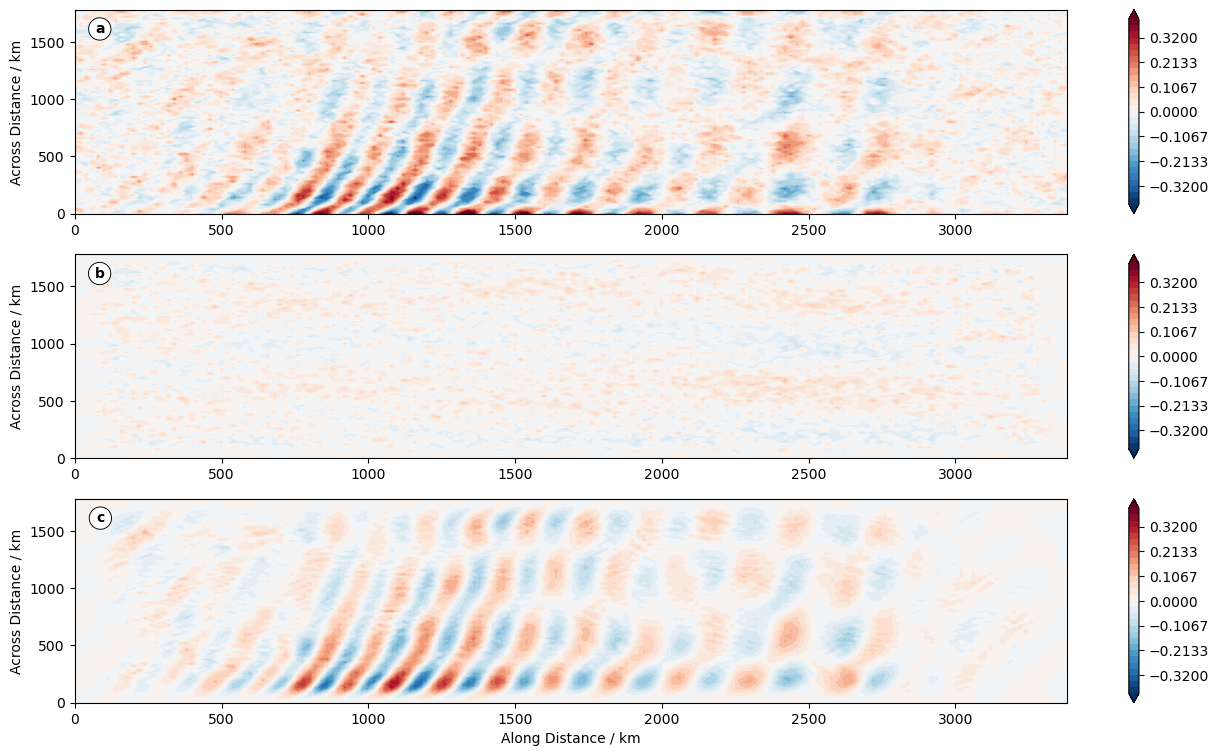

In [9]:
data_lev = np.linspace(-0.4,0.4,31)
fig = plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(311)
plot_orig = ax1.contourf(x,y,orig.T,levels=data_lev,extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_orig)

ax2 = fig.add_subplot(312)
plot_dirt = ax2.contourf(x,y,BI_low.T+signal.T-wavy_stuff.T+np.mean(orig.values),levels=data_lev,extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_dirt)

ax3 = fig.add_subplot(313)
plot_wave = ax3.contourf(x,y,wavy_stuff.T,levels=data_lev,extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_wave)

ax3.set_xlabel('Along Distance / km')
ax1.set_ylabel('Across Distance / km')
ax2.set_ylabel('Across Distance / km')
ax3.set_ylabel('Across Distance / km')

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
ax1.text(0.03,0.94,'a',transform=ax1.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax2.text(0.03,0.94,'b',transform=ax2.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax3.text(0.03,0.94,'c',transform=ax3.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 

In [10]:
WAS        = np.abs(denoised_cwt['decomposition'])
start_time = time.time()
seg_v1     = two.wavefield_segmentation_2d(WAS,0.1*noise_level,connectivity=1)
print("--- %s seconds ---" % (time.time() - start_time))
print('Identified', np.max(seg_v1), 'initial wave packets!')

k     = 2 * np.pi / cwt_result["period"]
theta = cwt_result["theta"]
eps   = np.abs(np.diff(np.log(k)))[0]*np.sqrt(2)
labels, cluster_labels = two.find_clusters_logk_theta(denoised_cwt, seg_v1, eps=eps)
cluster_map            = two.build_cluster_map_with_noise(labels,cluster_labels)
seg_v2                 = two.relabel_by_xy_overlap(seg_v1, cluster_map)
print('Number of wave packets after Clustering', np.max(seg_v2))

--- 69.748455286026 seconds ---
Identified 288 initial wave packets!
suggested scaling: 0.8549629505915273
Number of wave packets after Clustering 39


In [11]:
seg_v3 = two.variance_filter(denoised_cwt, seg_v2, var_threshold=0.99)
print('Final number of wave packets:', np.max(seg_v3))

Final number of wave packets: 4


In [12]:
recon_WP, amp_WP, k_along_WP, k_across_WP = two.recon_allWP_2d(denoised_cwt, seg_v3)
lh_WP, th_WP = two.kxky_2_lhtheta(k_along_WP,k_across_WP)

100%|██████████| 15300/15300 [00:00<00:00, 25923.45it/s]
/home/r/Robert.Reichert/WAVEGUISE/scripts/waveguise_2d.py:949: RuntimeWarning: divide by zero encountered in divide
  return 2*np.pi/k, theta


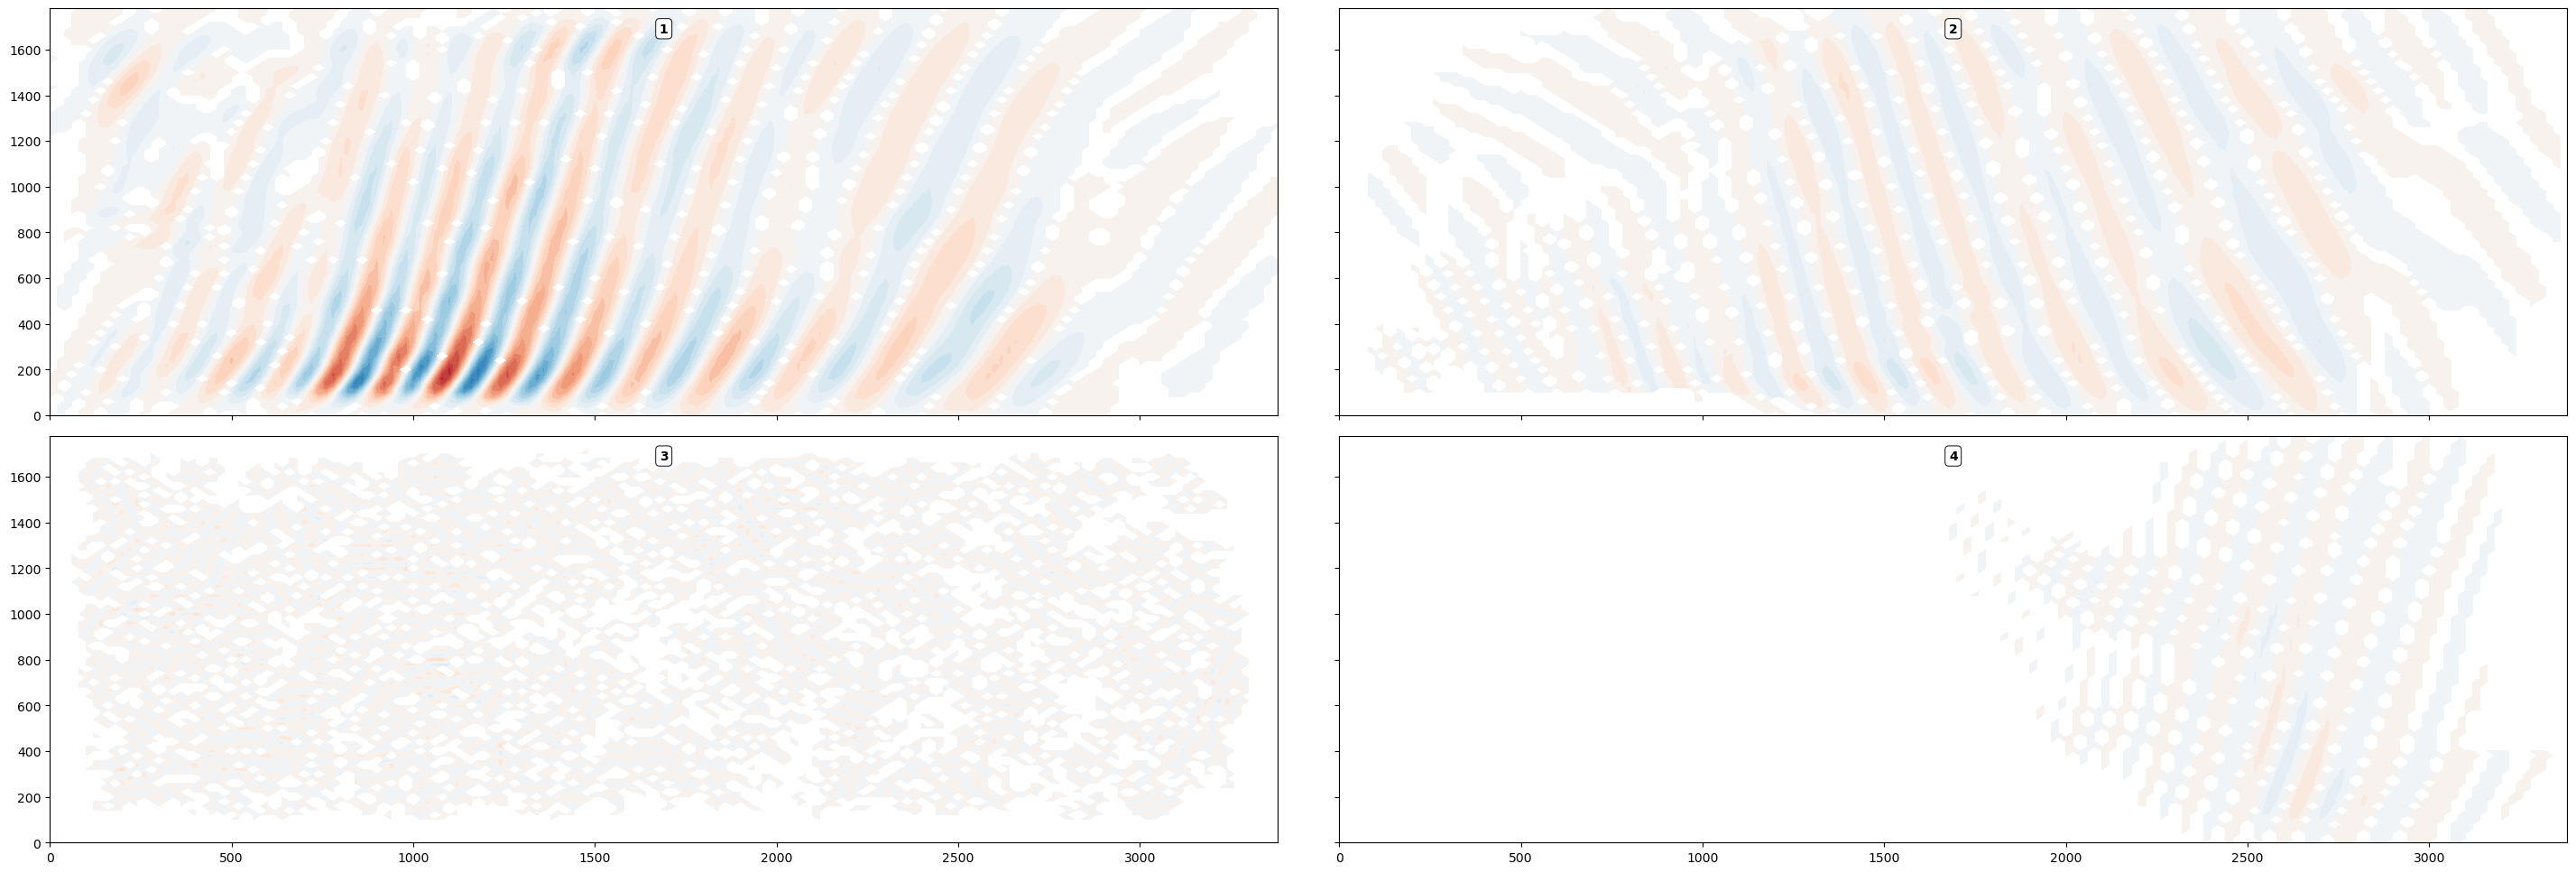

In [13]:
data_lev = np.linspace(-0.4,0.4,31)
row, col = pt.define_figgrid(recon_WP.shape[0])
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": col*[1], "height_ratios": row*[1]}

fig, ax=plt.subplots(row,col, figsize=(36,12), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(row):
    for j in range(col):
        if i*col+j < recon_WP.shape[0]:
            #ax[i][j].contourf(the_new_shit[i*col+j,:,:],levels=rad_lev,extend="both",cmap="RdBu_r")
            masked = np.ma.masked_inside(recon_WP[i*col+j,:,:], -noise_level*0.1, noise_level*0.1)  
            norm = mcolors.TwoSlopeNorm(vmin=data_lev[0], vcenter=0.0, vmax=data_lev[-1])
            ax[i,j].contourf(x,y,masked.T,levels=data_lev,cmap="RdBu_r",norm=norm,extend='both')
            ax[i,j].text(0.5, 0.95, str(i*col+j+1), verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})